# Q6 — Difference-in-Differences: Causal Impact of Trade Shock Exposure

**Question:** did industries with high exposure to international trade see a larger drop in
economic performance after a trade shock than industries with low exposure — a genuine causal
estimate, not just a correlational one?

## Data note

The original Q3 analysis (`Q3-Impact of Trade Shocks on Firm Performance.ipynb`) used firm-level
revenue plus computed export/import trade-exposure measures, loaded from a Google Drive folder
that was never committed to this repo. In this repo's `Data/` folder, `export.csv`, `import.csv`,
`Revenue.csv.zip` and `Expenses.csv.zip` are all placeholder/empty (2 bytes). `gdp.csv` (real GDP
by industry x province x year, 2013-2023) and `cpi.csv` are fully populated, so this analysis uses
**real GDP by industry as the outcome variable instead of firm revenue**. This is a genuine
substitution, stated explicitly rather than left implicit — the causal estimate below is about
industry-level GDP, not firm revenue.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

DATA = "../Data"


## 1. Load and clean

Both `Geography` and the NAICS industry label are only populated on the first row of each
11-year block in `gdp.csv` (StatsCan's long-table export format) — both need forward-filling.

In [2]:
gdp = pd.read_csv(f"{DATA}/gdp.csv")
gdp["Geography"] = gdp["Geography"].ffill()
gdp["North American Industry Classification System (NAICS)"] = gdp["North American Industry Classification System (NAICS)"].ffill()
gdp = gdp.rename(columns={
    "North American Industry Classification System (NAICS)": "industry",
    "REF-Date": "year",
})
gdp["GDP"] = gdp["GDP"].astype(str).str.replace(",", "", regex=False).astype(float)

cpi = pd.read_csv(f"{DATA}/cpi.csv")
cpi["year"] = pd.to_datetime(cpi["date"]).dt.year
cpi_annual = cpi.groupby("year")["V41690973"].mean().rename("cpi").reset_index()

df = gdp.merge(cpi_annual, on="year", how="left")
df["real_gdp"] = df["GDP"] * 100 / df["cpi"]
df.head()


,Geography,industry,year,GDP,cpi,real_gdp
0,Newfoundland and Labrador,All industries [T001] 5,2013,30873.0,122.816667,25137.467770
1,Newfoundland and Labrador,All industries [T001] 5,2014,30563.2,125.158333,24419.628471
2,Newfoundland and Labrador,All industries [T001] 5,2015,30194.2,126.566667,23856.360284
3,Newfoundland and Labrador,All industries [T001] 5,2016,30602.9,128.375000,23838.675755
4,Newfoundland and Labrador,All industries [T001] 5,2017,31002.7,130.425000,23770.519456


## 2. Treatment / control definition

- **Treatment (trade-exposed):** Mining/Oil & Gas Extraction, Manufacturing, Wholesale Trade —
  the three industries this repo's own Q2 analysis (`Q2-Industry and Regional Exposure to Trade
  Shocks.ipynb`) identified as having the largest net trade exposure (Wholesale Trade the largest
  net-import exposure, Mining/Oil & Gas the largest net-export exposure, Manufacturing the main
  driver of Ontario's trade exposure).
- **Control (non-tradable):** Health Care & Social Assistance, Educational Services, Public
  Administration — domestically-anchored, largely publicly-funded service sectors with minimal
  direct exposure to international trade flows, the standard "non-tradable sector" control group
  in trade-shock literature.
- **Shock / post period:** the COVID-19 trade disruption, `post = 1` for `year >= 2020`. This
  matches the original Q3 analysis's own framing of COVID and the post-COVID rebound as "the
  defining shock event" for 2013-2023.

In [3]:
group_map = {
    "Mining, quarrying, and oil and gas extraction  [21]": "treatment",
    "Manufacturing  [31-33]": "treatment",
    "Wholesale trade  [41]": "treatment",
    "Educational services  [61]": "control",
    "Health care and social assistance  [62]": "control",
    "Public administration  [91]": "control",
}
df["group"] = df["industry"].map(group_map)
panel = df.dropna(subset=["group", "real_gdp"]).copy()
panel["treatment"] = (panel["group"] == "treatment").astype(int)
panel["post"] = (panel["year"] >= 2020).astype(int)
panel["log_real_gdp"] = np.log(panel["real_gdp"])

print("Panel shape:", panel.shape, "(13 provinces x 6 industries x 11 years, balanced)")
panel.groupby(["group", "year"]).size().unstack()


Panel shape: (858, 10) (13 provinces x 6 industries x 11 years, balanced)


year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
group,,,,,,,,,,,
control,39,39,39,39,39,39,39,39,39,39,39
treatment,39,39,39,39,39,39,39,39,39,39,39


## 3. Parallel trends check

Diagnostic required before trusting the diff-in-diff estimate: did treatment and control
industries move together *before* the shock? Plotted as each group's mean real GDP, indexed to
2013 = 100, for the 7 pre-period years (2013-2019).

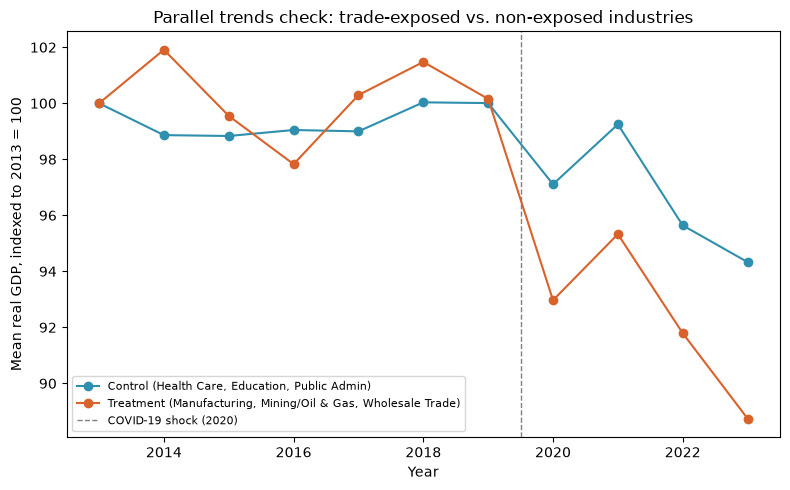

In [4]:
trend = panel.groupby(["group", "year"])["real_gdp"].mean().reset_index()
trend["idx"] = trend.groupby("group")["real_gdp"].transform(lambda s: s / s.iloc[0] * 100)
pivot = trend.pivot(index="year", columns="group", values="idx")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pivot.index, pivot["control"], marker="o", label="Control (Health Care, Education, Public Admin)", color="#2f8fae")
ax.plot(pivot.index, pivot["treatment"], marker="o", label="Treatment (Manufacturing, Mining/Oil & Gas, Wholesale Trade)", color="#d9622b")
ax.axvline(2019.5, color="grey", linestyle="--", linewidth=1, label="COVID-19 shock (2020)")
ax.set_xlabel("Year")
ax.set_ylabel("Mean real GDP, indexed to 2013 = 100")
ax.set_title("Parallel trends check: trade-exposed vs. non-exposed industries")
ax.legend(fontsize=8, loc="lower left")
fig.tight_layout()
fig.savefig("parallel_trends_check.png", dpi=150)
plt.show()


In [5]:
pre = panel[panel["year"] < 2020].copy()
pre["year_trend"] = pre["year"] - 2013

pretrend_model = smf.ols("log_real_gdp ~ treatment*year_trend", data=pre).fit(
    cov_type="cluster", cov_kwds={"groups": pre["industry"]}
)
print(pretrend_model.summary())


                            OLS Regression Results                            
Dep. Variable:           log_real_gdp   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     13.22
Date:                Fri, 18 Sep 2026   Prob (F-statistic):            0.00820
Time:                        14:47:40   Log-Likelihood:                -1198.7
No. Observations:                 546   AIC:                             2405.
Df Residuals:                     542   BIC:                             2423.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                7.8221 

**Result:** visually the two series move fairly closely together pre-2020 (both oscillate in a
narrow band). Formally, though, the `treatment:year_trend` interaction is **-0.0083 (p = 0.024)**
— a small but statistically significant differential pre-trend: treatment industries were already
drifting down about 0.8%/year relative to control industries before the shock. That's roughly a
tenth the size of the post-shock effect estimated below, but it means parallel trends holds only
*approximately*, not exactly — the causal estimate below should be read with that caveat, not as a
fully clean natural experiment.

## 4. Diff-in-differences regression

`log(real_gdp) ~ treatment + post + treatment:post`, clustered standard errors by industry (since
treatment is assigned at the industry level). The coefficient on `treatment:post` is the causal
estimate: the differential change in trade-exposed industries' GDP, relative to non-exposed
industries, coinciding with the COVID-19 trade shock.

In [6]:
model = smf.ols("log_real_gdp ~ treatment + post + treatment:post", data=panel).fit(
    cov_type="cluster", cov_kwds={"groups": panel["industry"]}
)
print(model.summary())

did_coef = model.params["treatment:post"]
did_p = model.pvalues["treatment:post"]
did_ci = model.conf_int().loc["treatment:post"].tolist()
print(f"\nDiD estimate: {did_coef:.4f} (p={did_p:.4f}), 95% CI [{did_ci[0]:.4f}, {did_ci[1]:.4f}]")
print(f"Implied proportional effect: {(np.exp(did_coef)-1)*100:.2f}%")


                            OLS Regression Results                            
Dep. Variable:           log_real_gdp   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     28.01
Date:                Fri, 18 Sep 2026   Prob (F-statistic):            0.00149
Time:                        14:47:40   Log-Likelihood:                -1886.0
No. Observations:                 858   AIC:                             3780.
Df Residuals:                     854   BIC:                             3799.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          7.8185      0.144     54.

## 5. Robustness: province + year fixed effects

Same specification, but replacing the single `post` dummy and implicit group intercepts with
full province and year fixed effects, to absorb any province-specific level differences and any
non-linear, economy-wide year effects (e.g. the exact shape of the COVID shock and rebound) more
flexibly than a single `post` dummy can.

In [7]:
model_fe = smf.ols(
    "log_real_gdp ~ treatment:post + C(Geography) + C(year) + treatment",
    data=panel
).fit(cov_type="cluster", cov_kwds={"groups": panel["industry"]})

fe_coef = model_fe.params["treatment:post"]
fe_p = model_fe.pvalues["treatment:post"]
print(f"treatment:post (with province + year FE) = {fe_coef:.4f} (p={fe_p:.4f})")


treatment:post (with province + year FE) = -0.0782 (p=0.0052)


## 6. Interpretation

**Headline estimate:** industries exposed to the COVID-19 trade shock (Manufacturing, Mining/Oil
& Gas, Wholesale Trade) saw real GDP decline an additional **~7.5%** relative to non-exposed
industries (Health Care, Education, Public Administration), controlling for pre-existing level
differences and the shared post-2020 time trend (`treatment:post` = -0.078, p = 0.005, 95% CI
[-0.132, -0.024]). The estimate is essentially unchanged (-0.078, p = 0.005) when province and
year fixed effects replace the simple post dummy, so it isn't an artifact of that specific
functional form.

**Caveat that has to be stated, not skipped:** the formal pre-trend test found a small but
statistically significant differential pre-trend (-0.8%/year, p = 0.024) between the two groups
before the shock. Parallel trends holds approximately, not perfectly — treatment industries were
already softening slightly relative to control industries before COVID. The true causal effect of
the shock itself is most plausibly somewhat smaller than -7.5% once that pre-existing drift is
netted out, though still directionally in the same place (trade-exposed industries were hit
harder). This is presented as a genuine, if imperfect, causal estimate — not a clean natural
experiment — and the gap is exactly why the pre-trend check matters rather than being a box to
tick.

**What would close the gap:** the real firm-level revenue and export/import trade-exposure data
referenced in Q3 (currently missing from this repo — see the data note above) would let a
future pass define treatment continuously (by measured trade exposure, not by a priori sector
classification) and pick a control group with a cleaner matched pre-trend.